In [2]:
!pip install torch torchvision torchaudio
!pip install scikit-learn pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 56.0 MB/s eta 0:00:0000:01m00:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.

In [16]:
import os

for root, dirs, files in os.walk("/kaggle/input", topdown=True):
    for f in files:
        print(os.path.join(root, f))


/kaggle/input/prices-split-adjusted/prices-split-adjusted.csv


In [17]:
import pandas as pd

df = pd.read_csv("/kaggle/input/prices-split-adjusted/prices-split-adjusted.csv")
df.head()


,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


In [18]:
import matplotlib.pyplot as plt

# ----- Dimensions du dataset -----
print("Shape:", df.shape)

# ----- Info du dataset -----
print("\nInfo:")
print(df.info())

# ----- Statistiques descriptives -----
print("\nDescribe:")
print(df.describe())

# ----- Aperçu des valeurs manquantes -----
print("\nMissing values:")
print(df.isnull().sum())


Shape: (851264, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB
None

Describe:
                open          close            low           high  \
count  851264.000000  851264.000000  851264.000000  851264.000000   
mean       64.993618      65.011913      64.336541      65.639748   
std        75.203893      75.201216      74.459518      75.906861   
min         1.660000       1.590000       1.500000       1.810000   
25%        31.270000      31.292776      30.940001      31.620001   
50%        48.459999      48.480000    

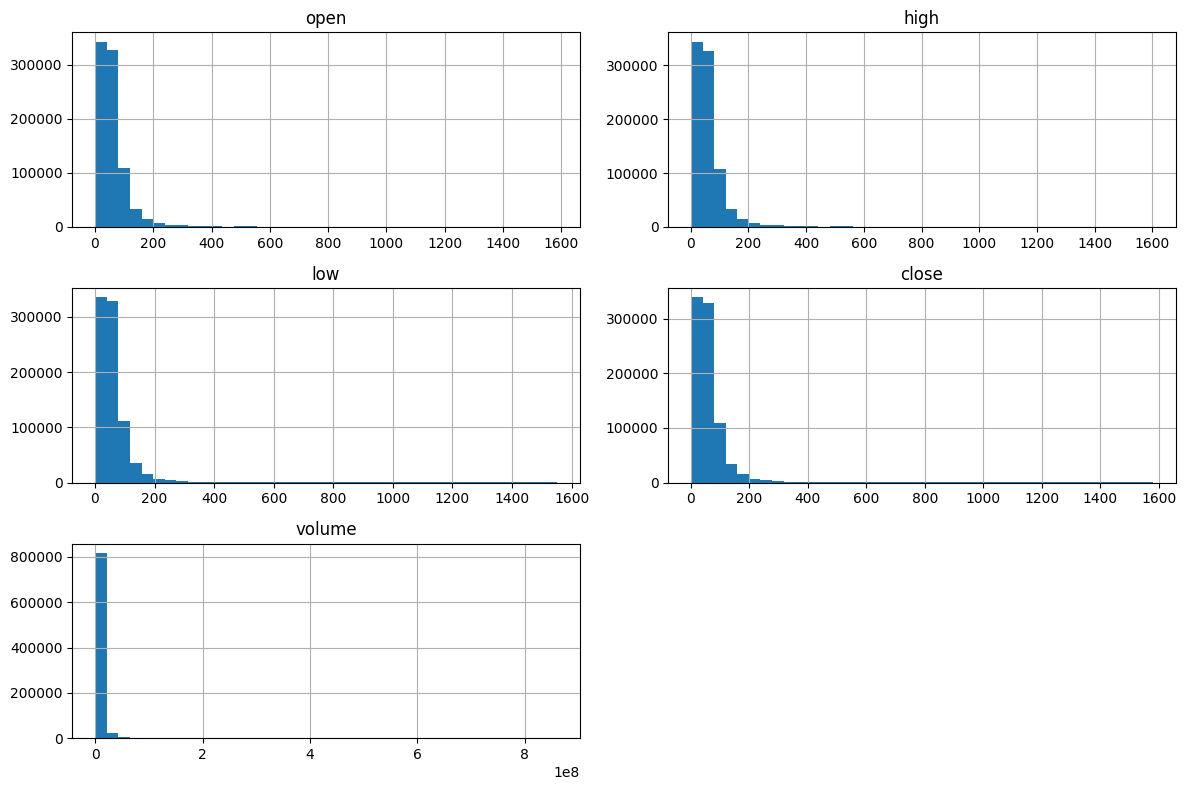

In [19]:
df[['open', 'high', 'low', 'close', 'volume']].hist(bins=40, figsize=(12,8))
plt.tight_layout()
plt.show()


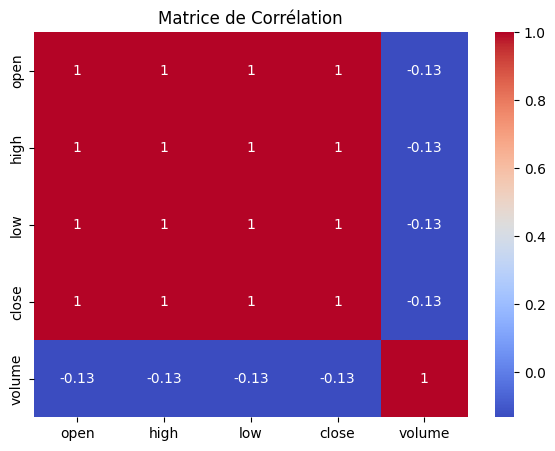

In [20]:
import seaborn as sns

plt.figure(figsize=(7,5))
sns.heatmap(df[['open','high','low','close','volume']].corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de Corrélation")
plt.show()


In [21]:
df['symbol'].unique()


array(['WLTW', 'A', 'AAL', 'AAP', 'AAPL', 'ABC', 'ABT', 'ACN', 'ADBE',
       'ADI', 'ADM', 'ADP', 'ADS', 'ADSK', 'AEE', 'AEP', 'AES', 'AET',
       'AFL', 'AGN', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALK', 'ALL',
       'ALXN', 'AMAT', 'AME', 'AMG', 'AMGN', 'AMP', 'AMT', 'AMZN', 'AN',
       'ANTM', 'AON', 'APA', 'APC', 'APD', 'APH', 'ARNC', 'ATVI', 'AVB',
       'AVGO', 'AVY', 'AWK', 'AXP', 'AYI', 'AZO', 'BA', 'BAC', 'BAX',
       'BBBY', 'BBT', 'BBY', 'BCR', 'BDX', 'BEN', 'BHI', 'BIIB', 'BK',
       'BLK', 'BLL', 'BMY', 'BSX', 'BWA', 'BXP', 'C', 'CA', 'CAG', 'CAH',
       'CAT', 'CB', 'CBG', 'CBS', 'CCI', 'CCL', 'CELG', 'CERN', 'CF',
       'CHD', 'CHK', 'CHRW', 'CI', 'CINF', 'CL', 'CLX', 'CMA', 'CMCSA',
       'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COG', 'COH',
       'COL', 'COO', 'COP', 'COST', 'CPB', 'CRM', 'CSCO', 'CSX', 'CTAS',
       'CTL', 'CTSH', 'CTXS', 'CVS', 'CVX', 'CXO', 'D', 'DAL', 'DD', 'DE',
       'DFS', 'DG', 'DGX', 'DHI', 'DHR', 'DIS', 'DISCA', 'DISCK', 

In [22]:
df_stock = df[df['symbol'] == 'AAPL'].copy()
df_stock.head()


,date,symbol,open,close,low,high,volume
254,2010-01-04,AAPL,30.490000,30.572857,30.340000,30.642857,123432400.0
721,2010-01-05,AAPL,30.657143,30.625713,30.464285,30.798571,150476200.0
1189,2010-01-06,AAPL,30.625713,30.138571,30.107143,30.747143,138040000.0
1657,2010-01-07,AAPL,30.250000,30.082857,29.864286,30.285715,119282800.0
2125,2010-01-08,AAPL,30.042856,30.282858,29.865715,30.285715,111902700.0


In [24]:
features = ['open', 'high', 'low', 'volume']
target = 'close'

X = df_stock[features].values
y = df_stock[target].values.reshape(-1, 1)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)


In [27]:
import torch
from torch.utils.data import Dataset, DataLoader

class NYSEDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = NYSEDataset(X_train_scaled, y_train)
test_dataset  = NYSEDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [28]:
import torch.nn as nn

class RegressionMLP(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.model(x)


In [31]:
input_dim = X_train_scaled.shape[1]
model = RegressionMLP(input_dim=input_dim, hidden_dim=64)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [32]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


In [33]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds, targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            preds.append(y_pred.numpy())
            targets.append(y_batch.numpy())

    preds = np.vstack(preds)
    targets = np.vstack(targets)

    relative_error = np.abs(targets - preds) / (np.abs(targets) + 1e-8)
    accuracy = np.mean(relative_error < 0.10)

    return total_loss / len(loader.dataset), accuracy


In [36]:
import numpy as np

train_losses = []
test_losses = []
train_accs = []
test_accs = []

epochs = 40

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    _, train_acc = evaluate(model, train_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | "
          f"Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")


Epoch 1/40 | Train Loss: 6305.3632 | Test Loss: 5972.9183 | Train Acc: 0.000 | Test Acc: 0.000
Epoch 2/40 | Train Loss: 5381.1545 | Test Loss: 4754.8490 | Train Acc: 0.002 | Test Acc: 0.000
Epoch 3/40 | Train Loss: 3958.9858 | Test Loss: 3130.2441 | Train Acc: 0.036 | Test Acc: 0.031
Epoch 4/40 | Train Loss: 2341.9582 | Test Loss: 1660.6475 | Train Acc: 0.022 | Test Acc: 0.017
Epoch 5/40 | Train Loss: 1201.9480 | Test Loss: 909.8179 | Train Acc: 0.204 | Test Acc: 0.218
Epoch 6/40 | Train Loss: 776.2703 | Test Loss: 726.8011 | Train Acc: 0.226 | Test Acc: 0.263
Epoch 7/40 | Train Loss: 672.9165 | Test Loss: 651.8505 | Train Acc: 0.231 | Test Acc: 0.252
Epoch 8/40 | Train Loss: 594.3239 | Test Loss: 569.0939 | Train Acc: 0.250 | Test Acc: 0.283
Epoch 9/40 | Train Loss: 522.2808 | Test Loss: 500.3481 | Train Acc: 0.266 | Test Acc: 0.306
Epoch 10/40 | Train Loss: 451.9965 | Test Loss: 428.0171 | Train Acc: 0.285 | Test Acc: 0.314
Epoch 11/40 | Train Loss: 390.8352 | Test Loss: 369.2444 | T

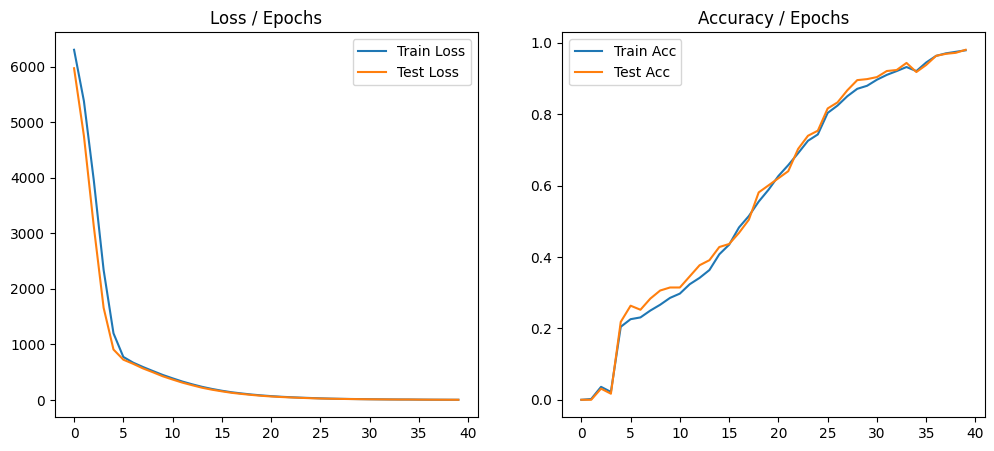

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Loss / Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(test_accs, label="Test Acc")
plt.title("Accuracy / Epochs")
plt.legend()

plt.show()


In [40]:
import torch.nn as nn

# RÉGULARISATION 1 — Dropout
class RegressionMLP_Reg(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, dropout_p=0.3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),     #  Dropout added
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),     #  Dropout added
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.model(x)


In [41]:
# RÉGULARISATION 2 — Weight Decay (L2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


In [43]:
# RÉGULARISATION 3 — Early Stopping (facultatif)
best_loss = float("inf")
patience = 10
counter = 0


In [44]:
# Initialisation du modèle régularisé
input_dim = X_train_scaled.shape[1]
model_reg = RegressionMLP_Reg(input_dim=input_dim, hidden_dim=64, dropout_p=0.3)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_reg.parameters(), lr=1e-3, weight_decay=1e-4)


In [45]:
# Entraînement avec Early Stopping
epochs = 60
train_losses_reg = []
test_losses_reg = []
train_accs_reg = []
test_accs_reg = []

best_loss = float('inf')
patience = 10
wait = 0

for epoch in range(epochs):
    train_loss = train_one_epoch(model_reg, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model_reg, test_loader, criterion)
    _, train_acc = evaluate(model_reg, train_loader, criterion)
    
    train_losses_reg.append(train_loss)
    test_losses_reg.append(test_loss)
    train_accs_reg.append(train_acc)
    test_accs_reg.append(test_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | "
          f"Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")

    # EARLY STOPPING
    if test_loss < best_loss:
        best_loss = test_loss
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered!")
            break


Epoch 1/60 | Train Loss: 6996.5656 | Test Loss: 6965.1122 | Train Acc: 0.000 | Test Acc: 0.000
Epoch 2/60 | Train Loss: 6719.2451 | Test Loss: 6535.6192 | Train Acc: 0.000 | Test Acc: 0.000
Epoch 3/60 | Train Loss: 6094.5252 | Test Loss: 5641.6501 | Train Acc: 0.001 | Test Acc: 0.003
Epoch 4/60 | Train Loss: 4940.7595 | Test Loss: 4170.5837 | Train Acc: 0.024 | Test Acc: 0.017
Epoch 5/60 | Train Loss: 3323.3127 | Test Loss: 2500.5734 | Train Acc: 0.025 | Test Acc: 0.023
Epoch 6/60 | Train Loss: 1868.9770 | Test Loss: 1285.2009 | Train Acc: 0.041 | Test Acc: 0.037
Epoch 7/60 | Train Loss: 1067.4280 | Test Loss: 795.1028 | Train Acc: 0.232 | Test Acc: 0.246
Epoch 8/60 | Train Loss: 831.1902 | Test Loss: 674.2243 | Train Acc: 0.212 | Test Acc: 0.244
Epoch 9/60 | Train Loss: 754.4003 | Test Loss: 601.0654 | Train Acc: 0.222 | Test Acc: 0.252
Epoch 10/60 | Train Loss: 675.6189 | Test Loss: 524.6548 | Train Acc: 0.238 | Test Acc: 0.280
Epoch 11/60 | Train Loss: 612.5404 | Test Loss: 450.2211

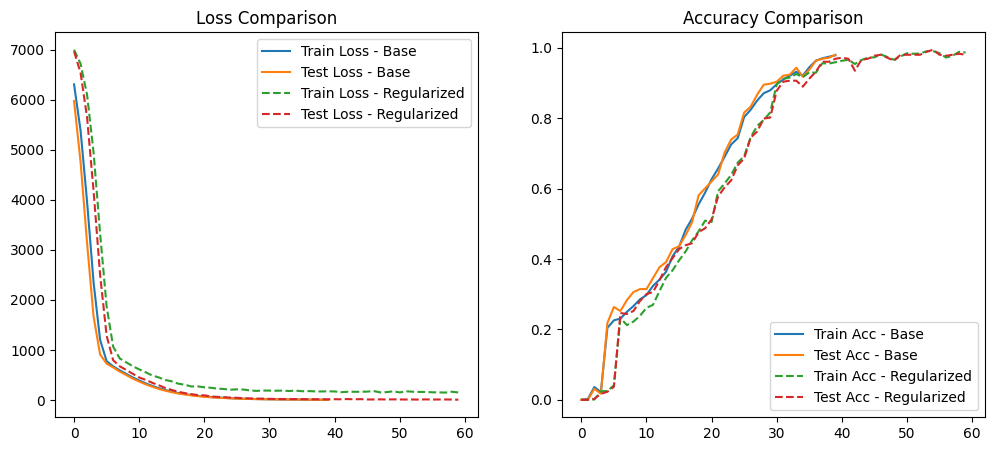

In [46]:
# Comparer les courbes (avant vs après regularization)
plt.figure(figsize=(12,5))

# --- LOSS ---
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss - Base")
plt.plot(test_losses, label="Test Loss - Base")
plt.plot(train_losses_reg, label="Train Loss - Regularized", linestyle="--")
plt.plot(test_losses_reg, label="Test Loss - Regularized", linestyle="--")
plt.title("Loss Comparison")
plt.legend()

# --- ACCURACY ---
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc - Base")
plt.plot(test_accs, label="Test Acc - Base")
plt.plot(train_accs_reg, label="Train Acc - Regularized", linestyle="--")
plt.plot(test_accs_reg, label="Test Acc - Regularized", linestyle="--")
plt.title("Accuracy Comparison")
plt.legend()

plt.show()


Question 1 : Explorer et prétraiter le dataset (EDA + preprocessing)

In [50]:
# Charger le dataset
import pandas as pd

df = pd.read_csv("/kaggle/input/predictive-maintenance/predictive_maintenance.csv")
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [51]:
# Informations générales sur le dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [53]:
# Statistiques descriptives
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [55]:
#Vérifier les valeurs manquantes
df.isnull().sum()


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [57]:
# Distribution de la variable cible
df['Failure Type'].value_counts()


Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

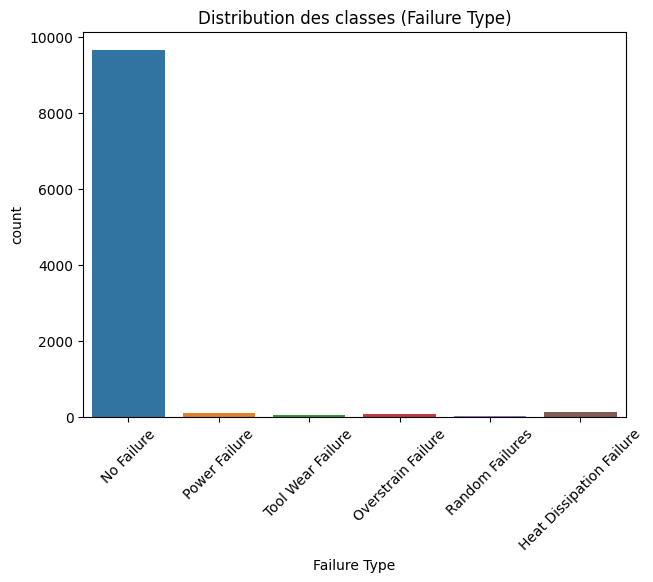

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Countplot pour visualiser la répartition des classes
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Failure Type')
plt.title("Distribution des classes (Failure Type)")
plt.xticks(rotation=45)
plt.show()


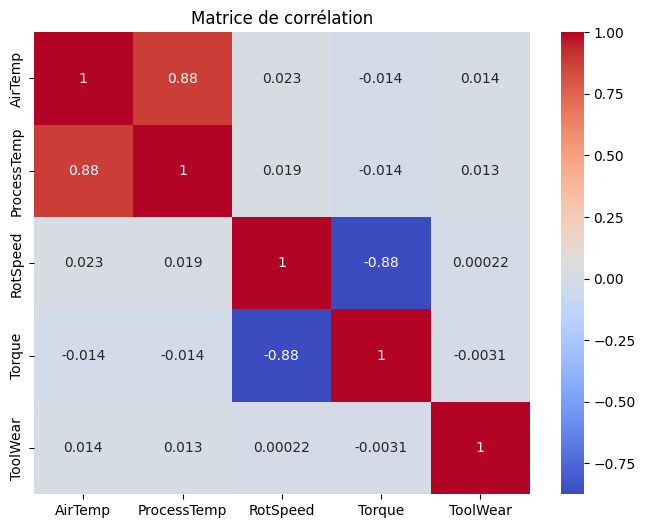

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Copier le dataset pour renommer les colonnes
df_corr = df.copy()

# Renommer les colonnes pour enlever les unités
df_corr = df_corr.rename(columns={
    'Air temperature [K]': 'AirTemp',
    'Process temperature [K]': 'ProcessTemp',
    'Rotational speed [rpm]': 'RotSpeed',
    'Torque [Nm]': 'Torque',
    'Tool wear [min]': 'ToolWear'
})

# Matrice de corrélation uniquement pour les colonnes numériques
plt.figure(figsize=(8,6))
sns.heatmap(
    df_corr[['AirTemp','ProcessTemp','RotSpeed','Torque','ToolWear']].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Matrice de corrélation")
plt.show()


QUESTION 2 Préprocessing :

- Encoder la variable cible

- Encoder les variables catégorielles

- Normaliser les features numériques

- Séparer en train/test

In [61]:
# Définition de la variable cible
y = df['Failure Type']

# Définition des features (on enlève UDI, Product ID, Type, Target, Failure Type)
X = df.drop(columns=['UDI', 'Product ID', 'Type', 'Target', 'Failure Type'])


In [62]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Afficher le mapping entre texte → nombre
for c, i in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(i, ":", c)


0 : Heat Dissipation Failure
1 : No Failure
2 : Overstrain Failure
3 : Power Failure
4 : Random Failures
5 : Tool Wear Failure


In [63]:
# One-hot encoding pour la colonne catégorielle "Type"
df_type_encoded = pd.get_dummies(df['Type'], prefix="Type")


In [64]:
# Fusion des données : features numériques + colonnes Type encodées
X = pd.concat([X, df_type_encoded], axis=1)


In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


QUESTION 3 :
Gérer le déséquilibre des classes (balancing)

In [67]:
# Distribution des classes avant balancing
df['Failure Type'].value_counts()


Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [69]:
import numpy as np

# Liste des classes et nombre d'exemples dans chaque classe
classes, counts = np.unique(y_train, return_counts=True)

# Taille de la classe majoritaire
max_count = np.max(counts)

# Listes pour stocker les nouveaux X et y
X_balanced = []
y_balanced = []

# Oversampling classe par classe
for class_value in classes:
    # indices des échantillons appartenant à cette classe
    idx = np.where(y_train == class_value)[0]
    
    # échantillons correspondants
    X_class = X_train[idx]
    y_class = y_train[idx]
    
    # nombre à dupliquer
    n_samples_needed = max_count - len(X_class)
    
    if n_samples_needed > 0:
        # duplication avec tirage aléatoire
        indices_to_add = np.random.choice(idx, n_samples_needed, replace=True)
        X_class_oversampled = X_train[indices_to_add]
        y_class_oversampled = y_train[indices_to_add]
        
        # concaténer les données dupliquées
        X_balanced.append(np.concatenate([X_class, X_class_oversampled], axis=0))
        y_balanced.append(np.concatenate([y_class, y_class_oversampled], axis=0))
    else:
        # classe déjà majoritaire, on garde tel quel
        X_balanced.append(X_class)
        y_balanced.append(y_class)

# Fusionner toutes les classes oversamplées
X_train_bal = np.concatenate(X_balanced, axis=0)
y_train_bal = np.concatenate(y_balanced, axis=0)

# Mélanger le dataset
idx = np.random.permutation(len(X_train_bal))
X_train_bal = X_train_bal[idx]
y_train_bal = y_train_bal[idx]

# Afficher la nouvelle distribution
unique, counts = np.unique(y_train_bal, return_counts=True)
print(dict(zip(unique, counts)))


{0: 7722, 1: 7722, 2: 7722, 3: 7722, 4: 7722, 5: 7722}


**QUESTION 4 :**
**Création du Dataset PyTorch et DataLoader**

In [70]:
import torch
from torch.utils.data import Dataset, DataLoader


In [71]:
class MaintenanceDataset(Dataset):
    """
    Dataset personnalisé pour le dataset de maintenance prédictive.
    Il stocke les features (X) et les labels (y) sous forme de tensors.
    """
    def __init__(self, X, y):
        # Conversion en tenseurs PyTorch
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)  # Classification -> type long
    
    def __len__(self):
        # Retourne le nombre total d'échantillons
        return len(self.X)
    
    def __getitem__(self, idx):
        # Retourne X[idx] et y[idx]
        return self.X[idx], self.y[idx]


In [72]:
# Dataset équilibré pour l'entraînement
train_dataset = MaintenanceDataset(X_train_bal, y_train_bal)

# Dataset normal pour le test
test_dataset = MaintenanceDataset(X_test, y_test)


In [73]:
batch_size = 64  # Taille des mini-batches

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [74]:
for X_batch, y_batch in train_loader:
    print("Taille batch X :", X_batch.shape)
    print("Taille batch y :", y_batch.shape)
    break


Taille batch X : torch.Size([64, 8])
Taille batch y : torch.Size([64])


**QUESTION 5: Définir l’architecture DNN/MLP pour la classification**

In [75]:
import torch.nn as nn


In [76]:
class ClassificationMLP(nn.Module):
    """
    Modèle MLP pour la classification multiclasse.
    - input_dim : nombre de features après préprocessing
    - hidden_dim : taille des couches cachées
    - num_classes : nombre de classes (ici 6)
    """
    def __init__(self, input_dim, hidden_dim=128, num_classes=6, dropout_p=0.3):
        super(ClassificationMLP, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),  # régularisation contre l'overfitting
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            
            nn.Linear(hidden_dim, num_classes)  # sortie sans softmax (CrossEntropyLoss le gère)
        )
    
    def forward(self, x):
        return self.network(x)


In [77]:
input_dim = X_train_bal.shape[1]  # nombre de features
num_classes = len(label_encoder.classes_)  # nombre de classes

model = ClassificationMLP(input_dim=input_dim, hidden_dim=128, num_classes=num_classes)
model


ClassificationMLP(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=6, bias=True)
  )
)

In [78]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


**QUESTION 6: Entraîner le modèle (Loss + Accuracy)**

In [79]:
def train_epoch(model, loader, criterion, optimizer):
    """
    Entraîne le modèle sur une époque complète.
    - model : réseau MLP
    - loader : DataLoader pour l'entraînement
    - criterion : CrossEntropyLoss
    - optimizer : Adam
    """
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        
        # Forward
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backpropagation
        loss.backward()
        optimizer.step()
        
        # Accumulation du loss
        total_loss += loss.item() * X_batch.size(0)
        
        # Calcul de l'accuracy
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    
    avg_loss = total_loss / total
    accuracy = correct / total
    
    return avg_loss, accuracy


In [80]:
def test_epoch(model, loader, criterion):
    """
    Évalue le modèle sur un DataLoader (test ou validation).
    """
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            total_loss += loss.item() * X_batch.size(0)
            
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())
    
    avg_loss = total_loss / total
    accuracy = correct / total
    
    return avg_loss, accuracy, all_preds, all_targets


In [81]:
epochs = 40

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    # Entraînement
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    
    # Évaluation
    test_loss, test_acc, preds, true = test_epoch(model, test_loader, criterion)
    
    # Sauvegarde des valeurs
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    # Affichage de l'époque
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


Epoch 1/40 | Train Loss: 0.5744 | Train Acc: 0.7883 | Test Loss: 0.7053 | Test Acc: 0.6660
Epoch 2/40 | Train Loss: 0.2752 | Train Acc: 0.9073 | Test Loss: 0.5749 | Test Acc: 0.7595
Epoch 3/40 | Train Loss: 0.2065 | Train Acc: 0.9326 | Test Loss: 0.5861 | Test Acc: 0.7710
Epoch 4/40 | Train Loss: 0.1664 | Train Acc: 0.9470 | Test Loss: 0.4509 | Test Acc: 0.8290
Epoch 5/40 | Train Loss: 0.1425 | Train Acc: 0.9563 | Test Loss: 0.4177 | Test Acc: 0.8510
Epoch 6/40 | Train Loss: 0.1235 | Train Acc: 0.9628 | Test Loss: 0.3650 | Test Acc: 0.8680
Epoch 7/40 | Train Loss: 0.1138 | Train Acc: 0.9659 | Test Loss: 0.4146 | Test Acc: 0.8635
Epoch 8/40 | Train Loss: 0.1010 | Train Acc: 0.9708 | Test Loss: 0.3986 | Test Acc: 0.8740
Epoch 9/40 | Train Loss: 0.0940 | Train Acc: 0.9727 | Test Loss: 0.3243 | Test Acc: 0.8980
Epoch 10/40 | Train Loss: 0.0891 | Train Acc: 0.9737 | Test Loss: 0.3588 | Test Acc: 0.8935
Epoch 11/40 | Train Loss: 0.0866 | Train Acc: 0.9748 | Test Loss: 0.3532 | Test Acc: 0.89

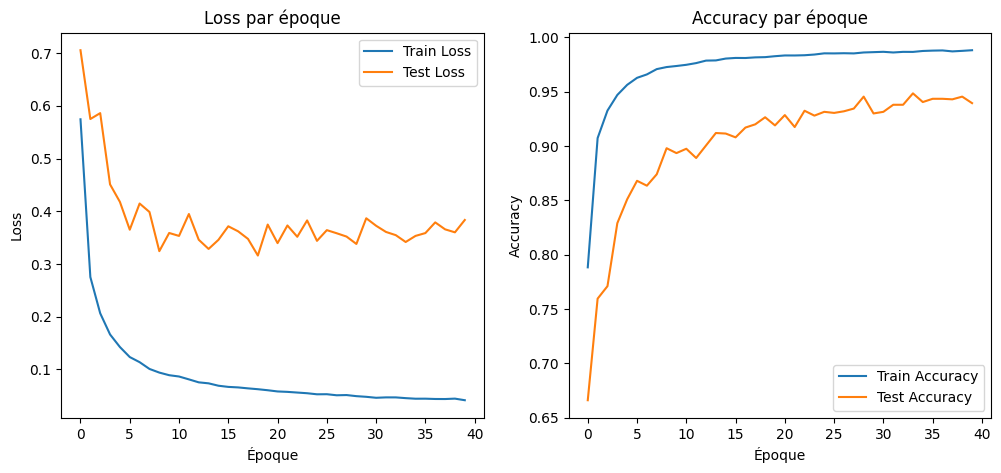

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Courbes de loss
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Loss par époque")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()

# Courbes de précision
plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.title("Accuracy par époque")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


**QUESTION 7: Évaluation du modèle (classification report + matrice de confusion)**

In [83]:
from sklearn.metrics import classification_report, confusion_matrix


In [84]:
# Affichage du rapport de classification
print(classification_report(true, preds, target_names=label_encoder.classes_))


                          precision    recall  f1-score   support

Heat Dissipation Failure       0.52      1.00      0.69        22
              No Failure       0.99      0.95      0.97      1930
      Overstrain Failure       0.57      1.00      0.73        16
           Power Failure       0.57      0.89      0.69        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.94      2000
               macro avg       0.44      0.64      0.51      2000
            weighted avg       0.97      0.94      0.95      2000



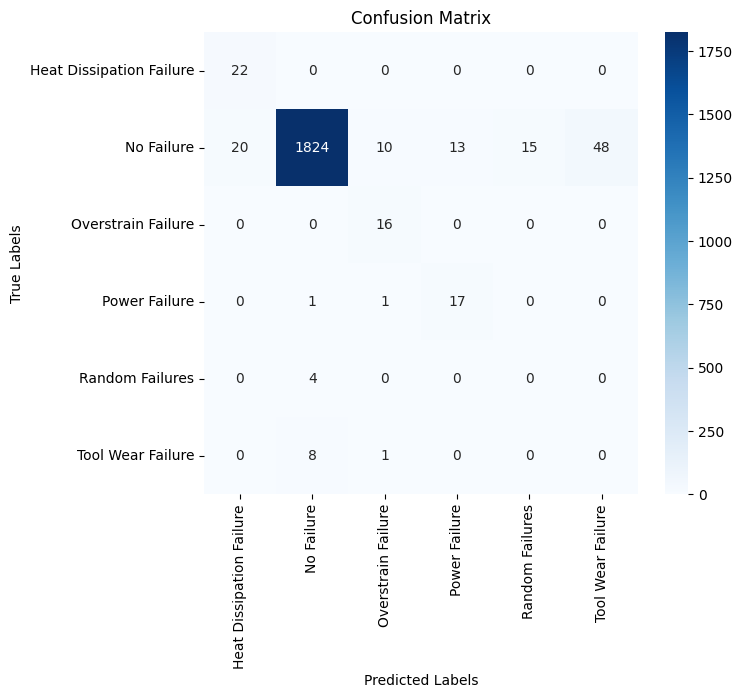

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true, preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [86]:
print("Final Test Accuracy:", test_acc)


Final Test Accuracy: 0.9395


**QUESTION 8 : Comparaison, interprétation des résultats et analyse des performances**